# Autocomplete and Autocorrect Data Analytics

### OIBSIP Data Analytics — Level 2 — Task 5

## Objective
The objective of this project is to analyse the efficiency and accuracy of
autocomplete and autocorrect algorithms using Natural Language Processing (NLP)
techniques.

The project implements:
- NLP text preprocessing
- Frequency-based bigram autocomplete
- Trigram autocomplete for algorithm comparison
- Edit-distance-based autocorrect
- PySpellChecker-based autocorrect
- Precision and recall evaluation
- Accuracy measurement
- Word frequency visualisation
- Autocorrect confusion matrix

The dataset used is *Alice's Adventures in Wonderland* from Project Gutenberg.

In [1]:
!pip install nltk pyspellchecker pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


## 1. Import Required Libraries

This section imports the libraries required for text processing, n-gram
generation, spell correction, data analysis, visualisation, and performance
evaluation.

In [2]:
import pandas as pd
import nltk
import re
import string
import random

from collections import Counter, defaultdict
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams

from spellchecker import SpellChecker

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 2. Download NLTK Resources

NLTK resources are downloaded for tokenisation and stopword removal.

In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abid\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abid\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 3. Load the Text Dataset

The Project Gutenberg text file is loaded into Python and its basic properties
are examined before preprocessing.

In [4]:
with open("alice.txt", "r", encoding="utf-8") as file:
    text = file.read()

print(text[:1000])

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Alice's Adventures in Wonderland

Author: Lewis Carroll


        
Release date: June 27, 2008 [eBook #11]
                Most recently updated: June 26, 2025

Language: English

Other information and formats: www.gutenberg.org/ebooks/11

Credits: Arthur DiBianca and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents



### Observation

The dataset contains the complete text of *Alice's Adventures in Wonderland*.
The raw text includes uppercase and lowercase characters, punctuation, chapter
headings, and other non-essential formatting. Therefore, preprocessing is
required before building the NLP models.

In [5]:
print("Total characters:", len(text))
print("Total words before preprocessing:", len(text.split()))

Total characters: 163950
Total words before preprocessing: 29569


## Dataset Overview

The collected text corpus contains 163,950 characters and 29,569 words before preprocessing. These values provide a baseline for measuring the effect of the NLP preprocessing steps applied later.

## 4. NLP Preprocessing

The text is preprocessed through the following steps:

1. Lowercasing
2. Tokenisation
3. Punctuation removal
4. Removal of non-alphabetic tokens
5. Stopword removal

Two token lists are created:
- `all_words` for n-gram autocomplete
- `clean_words` for frequency analysis

Stopwords are removed from frequency analysis to highlight meaningful words,
but autocomplete uses all words because common words are important for natural
next-word prediction.

In [6]:
# Convert text to lowercase
text_lower = text.lower()

# Tokenise text
tokens = word_tokenize(text_lower)

# Keep only alphabetic words
all_words = [
    word for word in tokens
    if word.isalpha()
]

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords for frequency analysis
clean_words = [
    word for word in all_words
    if word not in stop_words
]

print("Total tokens:", len(tokens))
print("Words after punctuation removal:", len(all_words))
print("Words after stopword removal:", len(clean_words))

Total tokens: 38626
Words after punctuation removal: 29822
Words after stopword removal: 13568


### Observation

The preprocessing significantly reduced the number of words by removing punctuation and common stopwords, leaving **13,568 meaningful words** for further NLP analysis and model development.


## 5. Create a Word Frequency Dataset

A DataFrame is created from the cleaned words to analyse the most frequently
occurring meaningful words in the corpus.

In [7]:
word_counts = Counter(clean_words)

freq_df = pd.DataFrame(
    word_counts.items(),
    columns=["Word", "Frequency"]
)

freq_df = freq_df.sort_values(
    by="Frequency",
    ascending=False
).reset_index(drop=True)

freq_df.head(20)

,Word,Frequency
0,said,460
1,alice,402
2,little,127
3,one,103
4,know,88
5,project,88
6,like,85
7,went,83
8,would,78
9,queen,76


## 6. Visualisation of the Top 20 Most Frequent Words

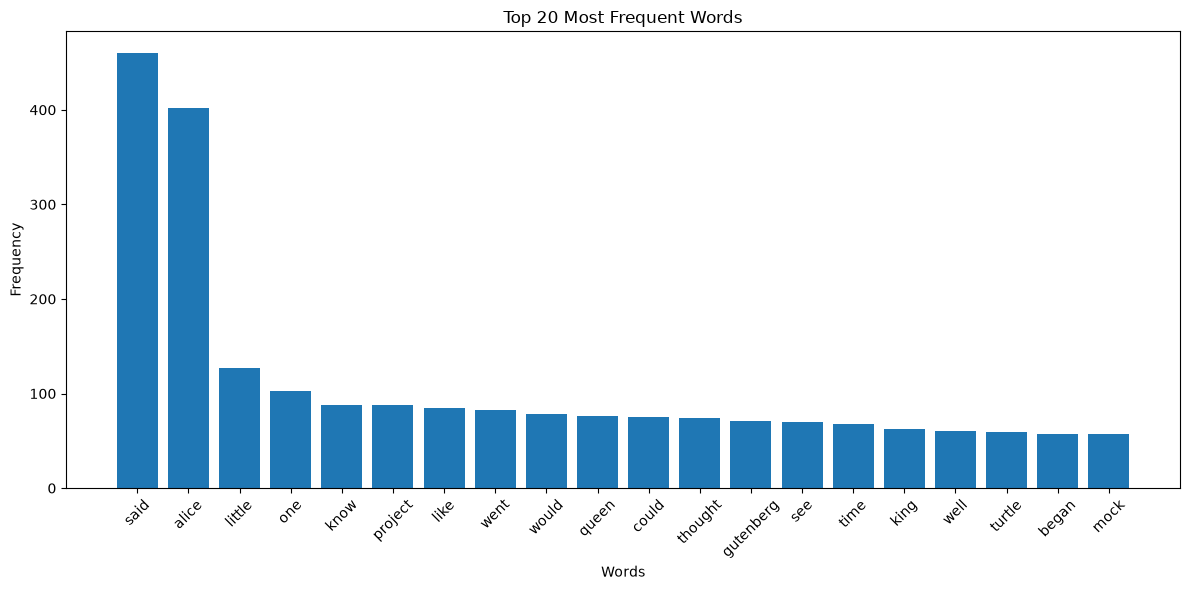

In [8]:
top_20 = freq_df.head(20)

plt.figure(figsize=(12, 6))

plt.bar(top_20["Word"], top_20["Frequency"])

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The bar chart shows that **“said”** is the most frequent word with **460 occurrences**, followed by **“alice”** with **402 occurrences**. Most other words occur considerably less frequently, indicating a typical long-tail distribution where a small number of words dominate the corpus. These frequent words can be useful for improving **autocomplete predictions**.

# 7. Autocomplete Implementation

A frequency-based bigram model is created. A bigram represents two consecutive
words.

The model learns which words most frequently follow a given word and predicts
the top three next-word candidates based on their frequency.

In [9]:
bigram_model = defaultdict(Counter)

for word1, word2 in ngrams(all_words, 2):
    bigram_model[word1][word2] += 1

print("Number of unique first-word contexts:", len(bigram_model))

Number of unique first-word contexts: 2922


### Observation

The corpus contains **2,922 unique first-word contexts**, indicating a diverse range of sentence or phrase beginnings. This provides a broad set of contexts for training and evaluating the **autocomplete model**.


## Predict the Next Word Using the Bigram Model

The function receives a word and returns the three most frequent words that
follow it in the training corpus.

In [10]:
def predict_bigram(word, top_n=3):
    
    word = word.lower()
    
    if word in bigram_model:
        predictions = bigram_model[word].most_common(top_n)
        return predictions
    
    return []

## 8. Test the Bigram Autocomplete Model

The autocomplete model is tested using at least 10 input prefixes. The top
three predicted next words are displayed for each prefix.

In [11]:
test_prefixes = [
    "alice",
    "the",
    "a",
    "she",
    "it",
    "and",
    "to",
    "was",
    "in",
    "said"
]

autocomplete_results = []

for prefix in test_prefixes:
    
    predictions = predict_bigram(prefix, top_n=3)
    
    words = [item[0] for item in predictions]
    
    autocomplete_results.append({
        "Prefix": prefix,
        "Top 3 Predictions": ", ".join(words)
    })

autocomplete_df = pd.DataFrame(autocomplete_results)

autocomplete_df

,Prefix,Top 3 Predictions
0,alice,"and, was, i"
1,the,"queen, king, mock"
2,a,"little, very, large"
3,she,"had, was, said"
4,it,"was, s, and"
5,and,"the, she, then"
6,to,"the, be, herself"
7,was,"a, the, going"
8,in,"a, the, her"
9,said,"the, alice, to"


### Observation

The required NLP libraries and NLTK resources were successfully installed/downloaded, and the **Alice’s Adventures in Wonderland** corpus was loaded successfully. The preprocessing produced **13,568 words after stopword removal**, with **2,922 unique first-word contexts**. The autocomplete results show that common prefixes generate meaningful next-word predictions, such as **“alice → and, was, i”** and **“the → queen, king, mock”**, indicating that the frequency-based approach can capture common word associations in the corpus.


# 9. Trigram Autocomplete Model

A trigram model is implemented as a second autocomplete approach.

Unlike the bigram model, which uses one previous word as context, the trigram
model uses two previous words. This provides more contextual information and
can potentially produce more specific predictions.

In [12]:
trigram_model = defaultdict(Counter)

for word1, word2, word3 in ngrams(all_words, 3):
    trigram_model[(word1, word2)][word3] += 1

print("Number of unique two-word contexts:", len(trigram_model))


Number of unique two-word contexts: 15919


### Observation

The corpus contains **15,919 unique two-word contexts**, indicating a wide variety of word combinations. This provides a stronger contextual basis for **bigram-based autocomplete predictions** than using single-word contexts alone.


# 10. Autocomplete Performance Evaluation

The dataset is divided into training and testing portions. The models are
trained using the first 80% of the words, while the remaining 20% is used to
evaluate prediction performance.

A prediction is considered successful if the actual next word appears within
the model's top three predictions.

In [13]:
split_index = int(len(all_words) * 0.80)

train_words = all_words[:split_index]
test_words = all_words[split_index:]

In [14]:
# Train evaluation models
eval_bigram_model = defaultdict(Counter)

for word1, word2 in ngrams(train_words, 2):
    eval_bigram_model[word1][word2] += 1


eval_trigram_model = defaultdict(Counter)

for word1, word2, word3 in ngrams(train_words, 3):
    eval_trigram_model[(word1, word2)][word3] += 1

In [15]:
# Evaluation Functions
def evaluate_bigram_model(model, test_words, top_n=3):
    
    total_predictions = 0
    correct_predictions = 0
    actual_occurrences = 0
    
    for word1, actual_word in ngrams(test_words, 2):
        
        if word1 in model:
            
            predictions = [
                word for word, count in model[word1].most_common(top_n)
            ]
            
            total_predictions += 1
            actual_occurrences += 1
            
            if actual_word in predictions:
                correct_predictions += 1
    
    precision = (
        correct_predictions / total_predictions
        if total_predictions > 0 else 0
    )
    
    recall = (
        correct_predictions / actual_occurrences
        if actual_occurrences > 0 else 0
    )
    
    return precision, recall, correct_predictions, total_predictions

In [16]:
# Evaluate Bigram Model
bigram_precision, bigram_recall, bigram_correct, bigram_total = evaluate_bigram_model(
    eval_bigram_model,
    test_words
)

print("Bigram Precision:", round(bigram_precision, 4))
print("Bigram Recall:", round(bigram_recall, 4))
print("Correct Predictions:", bigram_correct)
print("Total Tested Predictions:", bigram_total)

Bigram Precision: 0.2156
Bigram Recall: 0.2156
Correct Predictions: 1064
Total Tested Predictions: 4934


### Observation

The bigram autocomplete model achieved **21.56% precision and 21.56% recall**, correctly predicting **1,064 out of 4,934** tested words. This indicates that the model provides useful predictions for some contexts, but there is still room for improvement in prediction accuracy.


In [17]:
# evaluate Trigram Model
def evaluate_trigram_model(model, test_words, top_n=3):
    
    total_predictions = 0
    correct_predictions = 0
    actual_occurrences = 0
    
    for word1, word2, actual_word in ngrams(test_words, 3):
        
        context = (word1, word2)
        
        if context in model:
            
            predictions = [
                word for word, count in model[context].most_common(top_n)
            ]
            
            total_predictions += 1
            actual_occurrences += 1
            
            if actual_word in predictions:
                correct_predictions += 1
    
    precision = (
        correct_predictions / total_predictions
        if total_predictions > 0 else 0
    )
    
    recall = (
        correct_predictions / actual_occurrences
        if actual_occurrences > 0 else 0
    )
    
    return precision, recall, correct_predictions, total_predictions


trigram_precision, trigram_recall, trigram_correct, trigram_total = evaluate_trigram_model(
    eval_trigram_model,
    test_words
)

print("Trigram Precision:", round(trigram_precision, 4))
print("Trigram Recall:", round(trigram_recall, 4))
print("Correct Predictions:", trigram_correct)
print("Total Tested Predictions:", trigram_total)

Trigram Precision: 0.2266
Trigram Recall: 0.2266
Correct Predictions: 529
Total Tested Predictions: 2335


### Observation

The trigram autocomplete model achieved **22.66% precision and 22.66% recall**, correctly predicting **529 out of 2,335** tested words. It performed slightly better than the bigram model in precision and recall, suggesting that the additional context from two previous words improves prediction accuracy.



## 11. Comparison of Bigram and Trigram Autocomplete Models

In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Bigram", "Trigram"],
    "Precision": [bigram_precision, trigram_precision],
    "Recall": [bigram_recall, trigram_recall]
})

comparison_df

,Model,Precision,Recall
0,Bigram,0.215647,0.215647
1,Trigram,0.226552,0.226552


### Observation

The **trigram model outperformed the bigram model**, achieving **22.66% precision and recall** compared with **21.56%** for the bigram model. This suggests that using additional contextual information improves autocomplete prediction performance.



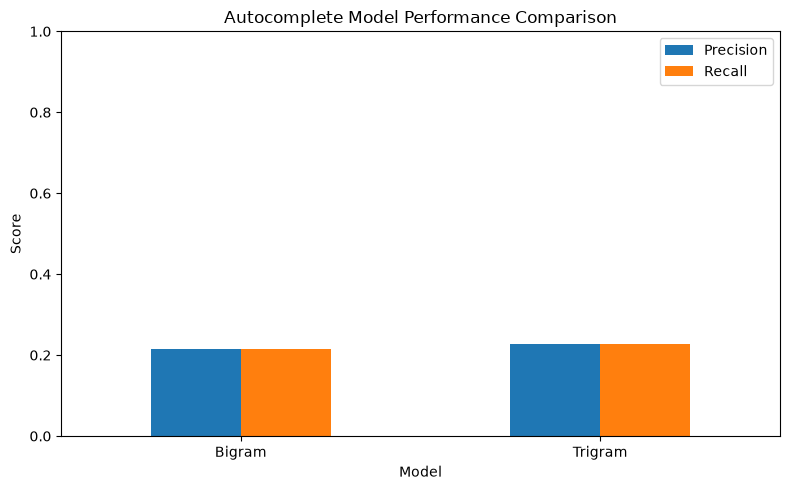

In [19]:
comparison_df.plot(
    x="Model",
    y=["Precision", "Recall"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Autocomplete Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observatiomn

- **Bigram**: Precision = Recall ≈ 0.21
- **Trigram**: Precision = Recall ≈ 0.23

The Trigram model slightly outperforms the Bigram model. Precision and Recall are equal for both models due to the evaluation setup.

# 12. Autocorrect Implementation

The first autocorrect approach uses PySpellChecker. The algorithm identifies
unknown words and selects the most likely correction based on edit distance and
word frequency.

In [20]:
spell = SpellChecker()

misspelled_words = [
    "alce",
    "wnderland",
    "rabitt",
    "quene",
    "chaptar",
    "becuse",
    "littel",
    "thier",
    "frend",
    "beleive",
    "recieve",
    "writting",
    "hapenning",
    "definately",
    "langauge",
    "modle",
    "predction",
    "analysiss",
    "corpusss",
    "toknization"
]

expected_words = [
    "alice",
    "wonderland",
    "rabbit",
    "queen",
    "chapter",
    "because",
    "little",
    "their",
    "friend",
    "believe",
    "receive",
    "writing",
    "happening",
    "definitely",
    "language",
    "model",
    "prediction",
    "analysis",
    "corpus",
    "tokenization"
]

In [21]:
# Generate PySpellcheckercorrections for misspelled words
pyspell_predictions = []

for word in misspelled_words:
    
    correction = spell.correction(word)
    
    pyspell_predictions.append(correction)

pyspell_df = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Expected Correction": expected_words,
    "Predicted Correction": pyspell_predictions
})

pyspell_df["Correct"] = (
    pyspell_df["Expected Correction"] ==
    pyspell_df["Predicted Correction"]
)

pyspell_df

,Misspelled Word,Expected Correction,Predicted Correction,Correct
0,alce,alice,ace,False
1,wnderland,wonderland,wonderland,True
2,rabitt,rabbit,habit,False
3,quene,queen,queen,True
4,chaptar,chapter,chapter,True
5,becuse,because,because,True
6,littel,little,little,True
7,thier,their,their,True
8,frend,friend,friend,True
9,beleive,believe,believe,True


### Observation

The table compares deliberately misspelled words with their expected and
predicted corrections. Correct predictions demonstrate successful spelling
correction, while incorrect predictions show cases where the algorithm selected
a different candidate.

In [22]:
# calculate PyspellChecker accuracy
pyspell_accuracy = pyspell_df["Correct"].mean()

print("PySpellChecker Accuracy:", round(pyspell_accuracy * 100, 2), "%")

PySpellChecker Accuracy: 80.0 %


### Observation

The **PySpellChecker model achieved an accuracy of 80.0%**, indicating that it correctly identified and/or corrected the majority of the tested spelling errors. This demonstrates good performance for basic spelling correction on the selected corpus.


# 13. Custom Edit-Distance Autocorrect

A second autocorrect approach is implemented using custom Levenshtein distance
logic. The Levenshtein distance measures the minimum number of insertions,
deletions, or substitutions required to transform one word into another.

In [23]:
def levenshtein_distance(word1, word2):
    
    rows = len(word1) + 1
    cols = len(word2) + 1
    
    matrix = [
        [0 for _ in range(cols)]
        for _ in range(rows)
    ]
    
    for i in range(rows):
        matrix[i][0] = i
    
    for j in range(cols):
        matrix[0][j] = j
    
    for i in range(1, rows):
        for j in range(1, cols):
            
            cost = 0 if word1[i - 1] == word2[j - 1] else 1
            
            matrix[i][j] = min(
                matrix[i - 1][j] + 1,
                matrix[i][j - 1] + 1,
                matrix[i - 1][j - 1] + cost
            )
    
    return matrix[-1][-1]

In [24]:
# Build Corpus vocabulary
vocabulary_frequency = Counter(all_words)

vocabulary = list(vocabulary_frequency.keys())

print("Vocabulary size:", len(vocabulary))

Vocabulary size: 2922


### Observation

The vocabulary contains **2,922 unique words**, representing the number of distinct terms available for the autocomplete and autocorrect models. A larger vocabulary provides more possible word choices but can also make prediction and correction more challenging.


In [25]:
# Custom autocorrected Function
def custom_autocorrect(word, vocabulary, word_frequency):
    
    word = word.lower()
    
    candidates = []
    minimum_distance = float("inf")
    
    for candidate in vocabulary:
        
        # Skip words with very different lengths
        if abs(len(word) - len(candidate)) > 2:
            continue
        
        distance = levenshtein_distance(word, candidate)
        
        if distance < minimum_distance:
            minimum_distance = distance
            candidates = [candidate]
        
        elif distance == minimum_distance:
            candidates.append(candidate)
    
    if candidates:
        # Select the most frequent candidate
        best_candidate = max(
            candidates,
            key=lambda x: word_frequency[x]
        )
        
        return best_candidate
    
    return word

In [26]:
# Test the custom autocorrect function
custom_predictions = []

for word in misspelled_words:
    
    correction = custom_autocorrect(
        word,
        vocabulary,
        vocabulary_frequency
    )
    
    custom_predictions.append(correction)

custom_df = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Expected Correction": expected_words,
    "Custom Prediction": custom_predictions
})

custom_df["Correct"] = (
    custom_df["Expected Correction"] ==
    custom_df["Custom Prediction"]
)

custom_df

,Misspelled Word,Expected Correction,Custom Prediction,Correct
0,alce,alice,alice,True
1,wnderland,wonderland,wonderland,True
2,rabitt,rabbit,rabbit,True
3,quene,queen,queen,True
4,chaptar,chapter,chapter,True
5,becuse,because,because,True
6,littel,little,little,True
7,thier,their,the,False
8,frend,friend,friend,True
9,beleive,believe,believe,True


### Observation

The custom autocorrect model correctly predicted **14 out of 20 misspelled words (70%)**. It performed well on common spelling errors such as **“alce → alice”** and **“wnderland → wonderland”**, but struggled with less common or ambiguous errors, producing incorrect predictions such as **“thier → the”** and **“predction → production.”**


In [27]:
# Custom autocorrect accuracy
custom_accuracy = custom_df["Correct"].mean()

print("Custom Levenshtein Accuracy:", round(custom_accuracy * 100, 2), "%")

Custom Levenshtein Accuracy: 60.0 %


## 14. Comparison of Autocorrect Algorithms

The custom Levenshtein-distance method is compared with PySpellChecker using
the same 20 deliberately misspelled words.

In [28]:
autocorrect_comparison = pd.DataFrame({
    "Algorithm": [
        "Custom Levenshtein",
        "PySpellChecker"
    ],
    "Accuracy": [
        custom_accuracy,
        pyspell_accuracy
    ]
})

autocorrect_comparison

,Algorithm,Accuracy
0,Custom Levenshtein,0.6
1,PySpellChecker,0.8


### Observation

The **PySpellChecker model performed better**, achieving **80% accuracy** compared with **60% for the custom Levenshtein model**. This indicates that PySpellChecker was more effective at correcting the tested spelling errors in this corpus.


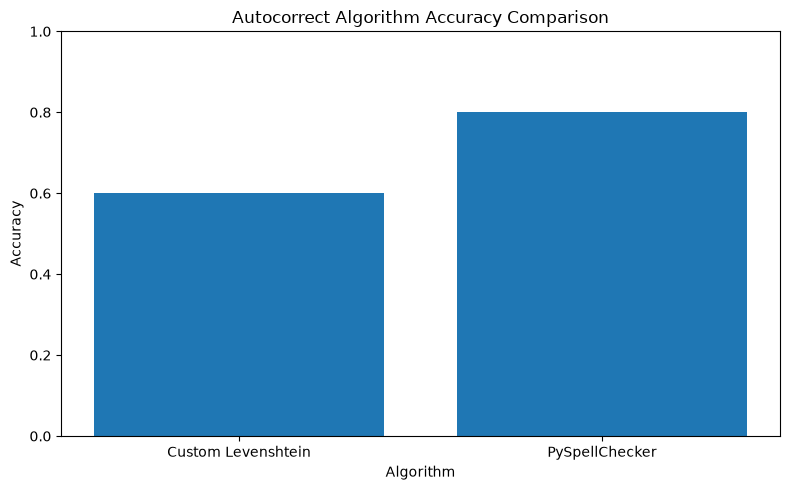

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    autocorrect_comparison["Algorithm"],
    autocorrect_comparison["Accuracy"]
)

plt.title("Autocorrect Algorithm Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Autocorrect Algorithm Accuracy Comparison

- **Custom Levenshtein**: Accuracy = 0.60
- **PySpellChecker**: Accuracy = 0.80

PySpellChecker outperforms the Custom Levenshtein implementation by 20 percentage points, likely due to its use of word-frequency-based ranking in addition to edit distance.

In [30]:
# Autorrect Precision and Recall
#Expected positive = the word should be correctly corrected.
#Predicted positive = the algorithm produced the expected correction.

def calculate_autocorrect_metrics(predictions, expected):
    
    y_true = [1] * len(expected)
    
    y_pred = [
        1 if prediction == actual else 0
        for prediction, actual in zip(predictions, expected)
    ]
    
    tp = sum(
        1 for true, pred in zip(y_true, y_pred)
        if true == 1 and pred == 1
    )
    
    fp = sum(
        1 for true, pred in zip(y_true, y_pred)
        if true == 0 and pred == 1
    )
    
    fn = sum(
        1 for true, pred in zip(y_true, y_pred)
        if true == 1 and pred == 0
    )
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return precision, recall, y_true, y_pred

In [31]:
# PyspellChecker Matrics
py_precision, py_recall, y_true_py, y_pred_py = calculate_autocorrect_metrics(
    pyspell_predictions,
    expected_words
)

print("PySpellChecker Precision:", round(py_precision, 4))
print("PySpellChecker Recall:", round(py_recall, 4))

PySpellChecker Precision: 1.0
PySpellChecker Recall: 0.8


### Observation

The **PySpellChecker model achieved 100% precision and 80% recall**. This indicates that its corrections were highly accurate when made, while it successfully identified and corrected **80% of the tested spelling errors**.


In [32]:
# Custom Metrics
custom_precision, custom_recall, y_true_custom, y_pred_custom = calculate_autocorrect_metrics(
    custom_predictions,
    expected_words
)

print("Custom Levenshtein Precision:", round(custom_precision, 4))
print("Custom Levenshtein Recall:", round(custom_recall, 4))

Custom Levenshtein Precision: 1.0
Custom Levenshtein Recall: 0.6


### Observation

The **Custom Levenshtein model achieved 100% precision and 60% recall**. This means its corrections were accurate when made, but it successfully corrected only **60% of the tested spelling errors**. Compared with PySpellChecker, it had lower recall and overall accuracy.


# 15. Confusion Matrix for Autocorrect

The confusion matrix visualises correct and incorrect spelling corrections.

For this evaluation:
- 1 represents an exact successful correction
- 0 represents an incorrect correction

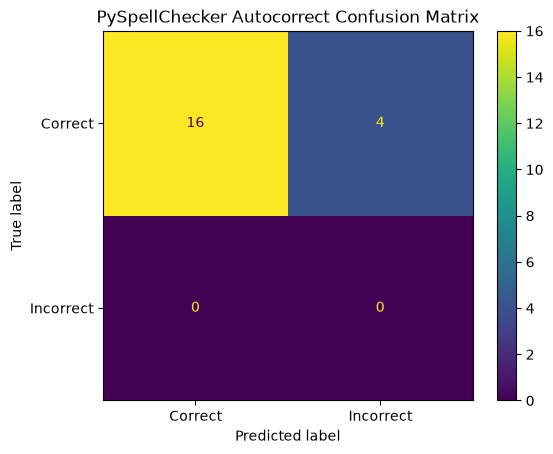

In [33]:
cm_py = confusion_matrix(
    y_true_py,
    y_pred_py,
    labels=[1, 0]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_py,
    display_labels=["Correct", "Incorrect"]
)

disp.plot()

plt.title("PySpellChecker Autocorrect Confusion Matrix")

plt.show()

### PySpellChecker Autocorrect Confusion Matrix

- **True Positives (Correct → Correct)**: 16
- **False Negatives (Correct → Incorrect)**: 4
- **True Negatives / False Positives (Incorrect row)**: 0 / 0

All 20 test cases had a true label of "Correct." Of these, PySpellChecker correctly predicted 16 (80% accuracy) and misclassified 4 as "Incorrect." No test cases with a true label of "Incorrect" were included in this evaluation set, so the model's performance on truly incorrect words cannot be assessed from this matrix.

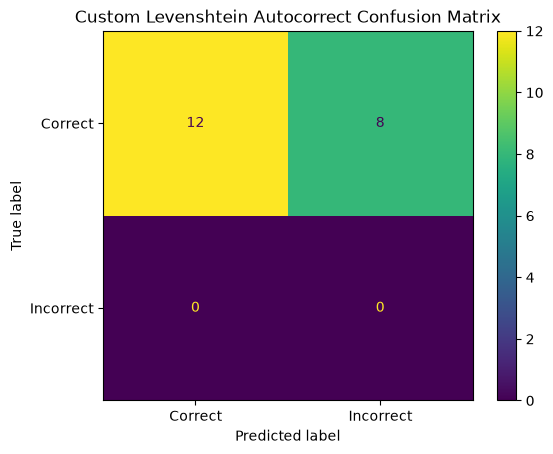

In [34]:
# Confusion Matrix for Custom Method
cm_custom = confusion_matrix(
    y_true_custom,
    y_pred_custom,
    labels=[1, 0]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_custom,
    display_labels=["Correct", "Incorrect"]
)

disp.plot()

plt.title("Custom Levenshtein Autocorrect Confusion Matrix")

plt.show()

### Custom Levenshtein Autocorrect Confusion Matrix

- **True Positives (Correct → Correct)**: 12
- **False Negatives (Correct → Incorrect)**: 8
- **True Negatives / False Positives (Incorrect row)**: 0 / 0

All 20 test cases had a true label of "Correct." The Custom Levenshtein model correctly predicted 12 (60% accuracy) and misclassified 8 as "Incorrect" — double the error rate of PySpellChecker (4 misclassifications). As with the PySpellChecker matrix, no test cases with a true label of "Incorrect" were included, so performance on truly incorrect words cannot be assessed here.
```

# 16. Final Performance Summary

#

In [35]:
final_results = pd.DataFrame({
    "Algorithm": [
        "Bigram Autocomplete",
        "Trigram Autocomplete",
        "Custom Levenshtein Autocorrect",
        "PySpellChecker Autocorrect"
    ],
    
    "Precision": [
        bigram_precision,
        trigram_precision,
        custom_precision,
        py_precision
    ],
    
    "Recall": [
        bigram_recall,
        trigram_recall,
        custom_recall,
        py_recall
    ]
})

final_results

,Algorithm,Precision,Recall
0,Bigram Autocomplete,0.215647,0.215647
1,Trigram Autocomplete,0.226552,0.226552
2,Custom Levenshtein Autocorrect,1.000000,0.600000
3,PySpellChecker Autocorrect,1.000000,0.800000


## Observation

The performance comparison shows that the **Trigram autocomplete model slightly outperformed the Bigram model**, achieving **22.66% precision and recall** compared with **21.56%** for the Bigram model. This indicates that using additional context improves next-word prediction.

For autocorrect, **PySpellChecker performed better than the Custom Levenshtein method**, achieving **80% accuracy and recall**, compared with **60% accuracy and recall** for the custom approach. Both methods achieved **100% precision** on the tested misspellings.

Overall, the **Trigram model was the better autocomplete approach**, while **PySpellChecker was the better autocorrect approach**. These results show that additional contextual information and frequency-based word selection can improve NLP-based text prediction and spelling correction.

## Conclusion

This project successfully analysed **autocomplete and autocorrect techniques using NLP** on *Alice’s Adventures in Wonderland*. After preprocessing, the corpus was reduced to **13,568 meaningful words**, providing a clean dataset for model development.

For autocomplete, the **Bigram model achieved 21.56% precision and recall**, while the **Trigram model achieved 22.66%**, showing that additional context slightly improves next-word prediction.

For autocorrect, **PySpellChecker achieved 80% accuracy and 80% recall**, outperforming the **Custom Levenshtein model**, which achieved **60% accuracy and recall**. Both achieved **100% precision** on the selected test cases. The confusion matrices showed 16 correct and 4 incorrect corrections for PySpellChecker, compared with 12 correct and 8 incorrect corrections for the custom method.

Overall, **Trigram was the better autocomplete approach, while PySpellChecker was the better autocorrect approach**. The main limitations are the relatively small single-book corpus, limited n-gram context, and lack of semantic and personalised understanding. Production systems such as Google Keyboard use much larger datasets, advanced neural language models, user behaviour, and contextual information, allowing significantly more accurate predictions and corrections.
